In [1]:
print('hello')

hello


In [2]:
import pandas as pd 
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path

## Carga de los datasets

In [3]:
datos = dict()
for i in range(1,7):
    nombre_archivo = f"../Simulaciones/sim_{i}_data.pkl"

    with open(nombre_archivo, 'rb') as f:
        datos_recuperados = pickle.load(f)
    datos[i]=datos_recuperados
    print(type(datos_recuperados),len(datos_recuperados))

<class 'dict'> 20
<class 'dict'> 20
<class 'dict'> 20
<class 'dict'> 20
<class 'dict'> 20
<class 'dict'> 20


## Remuestreo
Global, sobre la misma variable

In [4]:
from Funciones import remuestrear
datos_prueba = {'t_min': list(range(1,16)),
    'valores': [0, 10, 0, 0, 20, 0, 0, 30, 0, 0, 0, 40, 0,2,4]
}
df_prueba = pd.DataFrame(datos_prueba)

print("DataFrame Original:")
print(df_prueba)

salida = remuestrear(df_prueba, ['t_min', 'valores'], 5)
print("\nDataFrame con los valores desplazados:")
print(salida)

DataFrame Original:
    t_min  valores
0       1        0
1       2       10
2       3        0
3       4        0
4       5       20
5       6        0
6       7        0
7       8       30
8       9        0
9      10        0
10     11        0
11     12       40
12     13        0
13     14        2
14     15        4

DataFrame con los valores desplazados:
    t_min  valores
0       6       10
5      30       50
10     55       40
15     30        6


In [5]:
remuestrear(datos[3]['p_0'],columnas = ['meal_carb', 'snack_carb',
                                                     'bolus_insulin', 'basal_insulin'],
                                         t_muestreo=5)

,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
0,0.0,6.000000,108.0,0.0,0.0,0.0,30.013287,0.0
5,5.0,6.000000,108.0,0.0,0.0,0.0,0.000000,0.0
10,10.0,6.000000,108.0,0.0,0.0,0.0,0.000000,0.0
15,15.0,5.999987,108.0,0.0,0.0,0.0,0.000000,0.0
20,20.0,5.999729,108.0,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...
43180,43180.0,9.728406,175.0,0.0,0.0,0.0,0.000000,0.0
43185,43185.0,9.669671,174.0,0.0,0.0,0.0,0.000000,0.0
43190,43190.0,9.610650,173.0,0.0,0.0,0.0,0.000000,0.0
43195,43195.0,9.551680,172.0,0.0,0.0,0.0,0.000000,0.0


In [6]:
for s in range(1,7):
    for p in range(20):
        print(f'p{p}', end=' ')
        datos[s][f'p_{p}'] = remuestrear(datos[s][f'p_{p}'],
                                         columnas = ['meal_carb', 'snack_carb','bolus_insulin', 'basal_insulin'],
                                         t_muestreo=5)
    print('')

p0 p1 p2 p3 p4 p5 p6 p7 p8 p9 p10 p11 p12 p13 p14 p15 p16 p17 p18 p19 
p0 p1 p2 p3 p4 p5 p6 p7 p8 p9 p10 p11 p12 p13 p14 p15 p16 p17 p18 p19 
p0 p1 p2 p3 p4 p5 p6 p7 p8 p9 p10 p11 p12 p13 p14 p15 p16 p17 p18 p19 
p0 p1 p2 p3 p4 p5 p6 p7 p8 p9 p10 p11 p12 p13 p14 p15 p16 p17 p18 p19 
p0 p1 p2 p3 p4 p5 p6 p7 p8 p9 p10 p11 p12 p13 p14 p15 p16 p17 p18 p19 
p0 p1 p2 p3 p4 p5 p6 p7 p8 p9 p10 p11 p12 p13 p14 p15 p16 p17 p18 p19 


Escalado y Estandarizado

In [7]:
from Funciones import escalar,estandarizar

display(datos[3]['p_0'].head())
display(escalar(datos[3]['p_0']).head())
display(estandarizar(datos[3]['p_0']).head())
print(datos[3]['p_0']['gluc_mg'].min())

,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
0,0.0,6.000000,108.0,0.0,0.0,0.0,30.013287,0.0
5,5.0,6.000000,108.0,0.0,0.0,0.0,0.000000,0.0
10,10.0,6.000000,108.0,0.0,0.0,0.0,0.000000,0.0
15,15.0,5.999987,108.0,0.0,0.0,0.0,0.000000,0.0
20,20.0,5.999729,108.0,0.0,0.0,0.0,0.000000,0.0


,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
0,0.0,0.001242,0.0,0.0,0.0,0.0,1.0,0.0
5,5.0,0.001242,0.0,0.0,0.0,0.0,0.0,0.0
10,10.0,0.001242,0.0,0.0,0.0,0.0,0.0,0.0
15,15.0,0.001239,0.0,0.0,0.0,0.0,0.0,0.0
20,20.0,0.001187,0.0,0.0,0.0,0.0,0.0,0.0


,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
0,0.0,-3.930985,-3.931055,-0.099972,-0.083589,-0.099972,16.942058,-0.145123
5,5.0,-3.930985,-3.931055,-0.099972,-0.083589,-0.099972,-0.059025,-0.145123
10,10.0,-3.930985,-3.931055,-0.099972,-0.083589,-0.099972,-0.059025,-0.145123
15,15.0,-3.931003,-3.931055,-0.099972,-0.083589,-0.099972,-0.059025,-0.145123
20,20.0,-3.931340,-3.931055,-0.099972,-0.083589,-0.099972,-0.059025,-0.145123


108.0


## Históricos

In [8]:
# Ver primeras comidas
display(datos[1]['p_0'][datos[1]['p_0']['meal_carb']>0].head())

# Comprobar nuevos tamaños dfs
df_prueba = datos[1]['p_0']
print(df_prueba.shape)

# Eliminar columna glu_mmol
df_prueba = df_prueba.drop('glu_mmol', axis=1)
print(list(df_prueba.columns))

,t_min,glu_mmol,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
505,505.0,5.993836,108.0,43.377778,0.0,1.845863,0.0,0.0
860,860.0,7.667440,138.0,75.530303,0.0,3.214055,0.0,0.0
1265,1265.0,8.366782,151.0,56.058586,0.0,2.385472,0.0,0.0
1960,1960.0,7.767799,140.0,46.088889,0.0,1.961229,0.0,0.0
2295,2295.0,9.095991,164.0,81.360606,0.0,3.462153,0.0,0.0


(8641, 8)
['t_min', 'gluc_mg', 'meal_carb', 'snack_carb', 'bolus_insulin', 'basal_insulin', 'running_speed']


In [9]:
from Funciones import crear_features, indexar_temp
# Indice temporal
df_prueba = indexar_temp(df_prueba)
display(df_prueba.head())

# Generar histórico y separar
y , exog = crear_features(df_prueba)
display(y)
display(exog.head())

# Comprobar que no hay filas con valores nulos
filas_con_na = df_prueba[df_prueba.isnull().any(axis=1)]
print(len(filas_con_na))


,gluc_mg,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed
t_min,,,,,,
2026-01-01 00:00:00,108.0,0.0,0.0,0.0,30.013287,0.0
2026-01-01 00:05:00,108.0,0.0,0.0,0.0,0.000000,0.0
2026-01-01 00:10:00,108.0,0.0,0.0,0.0,0.000000,0.0
2026-01-01 00:15:00,108.0,0.0,0.0,0.0,0.000000,0.0
2026-01-01 00:20:00,108.0,0.0,0.0,0.0,0.000000,0.0


t_min
2026-01-01 04:00:00    108.0
2026-01-01 04:05:00    108.0
2026-01-01 04:10:00    108.0
2026-01-01 04:15:00    108.0
2026-01-01 04:20:00    108.0
                       ...  
2026-01-30 23:40:00    183.0
2026-01-30 23:45:00    182.0
2026-01-30 23:50:00    181.0
2026-01-30 23:55:00    180.0
2026-01-31 00:00:00    179.0
Freq: 5min, Name: gluc_mg, Length: 8593, dtype: float64

,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed,basal_-24h,meal_carb_-20m,meal_carb_-40m,meal_carb_-60m,meal_carb_-80m,...,running_speed_-60m,running_speed_-80m,running_speed_-100m,running_speed_-120m,running_speed_-140m,running_speed_-160m,running_speed_-180m,running_speed_-200m,running_speed_-220m,running_speed_-240m
t_min,,,,,,,,,,,,,,,,,,,,,
2026-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,30.013287,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01 04:05:00,0.0,0.0,0.0,0.0,0.0,30.013287,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01 04:10:00,0.0,0.0,0.0,0.0,0.0,30.013287,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01 04:15:00,0.0,0.0,0.0,0.0,0.0,30.013287,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01 04:20:00,0.0,0.0,0.0,0.0,0.0,30.013287,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


0


## Prueba de skforecast en 1 solo DataFrame

In [10]:
from skforecast.direct import ForecasterDirect
from xgboost import XGBRegressor
# Elminación de los valores nulos
print("DataFrame shape:", df_prueba.shape)
print("Columns:\n ", ", ".join(exog.columns.tolist()))
print("\nDate range:", df_prueba.index[0], "→", df_prueba.index[-1])

# División de 0,8 train y 0,2 test 
corte = round(df_prueba.shape[0]*0.8)

x_train = exog.iloc[:corte,:]
x_test = exog.iloc[corte:,]

y_train = y.iloc[:corte,]
y_test = y.iloc[corte:,]

display(x_train.head())
display(x_test.head())
display(y_train.head())
display(y_test.head())

print(len(x_train),len(x_test),len(x_train)+len(x_test))

DataFrame shape: (8641, 6)
Columns:
  meal_carb, snack_carb, bolus_insulin, basal_insulin, running_speed, basal_-24h, meal_carb_-20m, meal_carb_-40m, meal_carb_-60m, meal_carb_-80m, meal_carb_-100m, meal_carb_-120m, meal_carb_-140m, meal_carb_-160m, meal_carb_-180m, meal_carb_-200m, meal_carb_-220m, meal_carb_-240m, snack_carb_-20m, snack_carb_-40m, snack_carb_-60m, snack_carb_-80m, snack_carb_-100m, snack_carb_-120m, snack_carb_-140m, snack_carb_-160m, snack_carb_-180m, snack_carb_-200m, snack_carb_-220m, snack_carb_-240m, bolus_insulin_-20m, bolus_insulin_-40m, bolus_insulin_-60m, bolus_insulin_-80m, bolus_insulin_-100m, bolus_insulin_-120m, bolus_insulin_-140m, bolus_insulin_-160m, bolus_insulin_-180m, bolus_insulin_-200m, bolus_insulin_-220m, bolus_insulin_-240m, running_speed_-20m, running_speed_-40m, running_speed_-60m, running_speed_-80m, running_speed_-100m, running_speed_-120m, running_speed_-140m, running_speed_-160m, running_speed_-180m, running_speed_-200m, running_speed_-2

,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed,basal_-24h,meal_carb_-20m,meal_carb_-40m,meal_carb_-60m,meal_carb_-80m,...,running_speed_-60m,running_speed_-80m,running_speed_-100m,running_speed_-120m,running_speed_-140m,running_speed_-160m,running_speed_-180m,running_speed_-200m,running_speed_-220m,running_speed_-240m
t_min,,,,,,,,,,,,,,,,,,,,,
2026-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,30.013287,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01 04:05:00,0.0,0.0,0.0,0.0,0.0,30.013287,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01 04:10:00,0.0,0.0,0.0,0.0,0.0,30.013287,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01 04:15:00,0.0,0.0,0.0,0.0,0.0,30.013287,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01 04:20:00,0.0,0.0,0.0,0.0,0.0,30.013287,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,meal_carb,snack_carb,bolus_insulin,basal_insulin,running_speed,basal_-24h,meal_carb_-20m,meal_carb_-40m,meal_carb_-60m,meal_carb_-80m,...,running_speed_-60m,running_speed_-80m,running_speed_-100m,running_speed_-120m,running_speed_-140m,running_speed_-160m,running_speed_-180m,running_speed_-200m,running_speed_-220m,running_speed_-240m
t_min,,,,,,,,,,,,,,,,,,,,,
2026-01-25 04:05:00,0.0,0.0,0.0,0.0,0.0,30.013287,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-25 04:10:00,0.0,0.0,0.0,0.0,0.0,30.013287,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-25 04:15:00,0.0,0.0,0.0,0.0,0.0,30.013287,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-25 04:20:00,0.0,0.0,0.0,0.0,0.0,30.013287,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-25 04:25:00,0.0,0.0,0.0,0.0,0.0,30.013287,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


t_min
2026-01-01 04:00:00    108.0
2026-01-01 04:05:00    108.0
2026-01-01 04:10:00    108.0
2026-01-01 04:15:00    108.0
2026-01-01 04:20:00    108.0
Freq: 5min, Name: gluc_mg, dtype: float64

t_min
2026-01-25 04:05:00    152.0
2026-01-25 04:10:00    152.0
2026-01-25 04:15:00    152.0
2026-01-25 04:20:00    152.0
2026-01-25 04:25:00    152.0
Freq: 5min, Name: gluc_mg, dtype: float64

6913 1680 8593


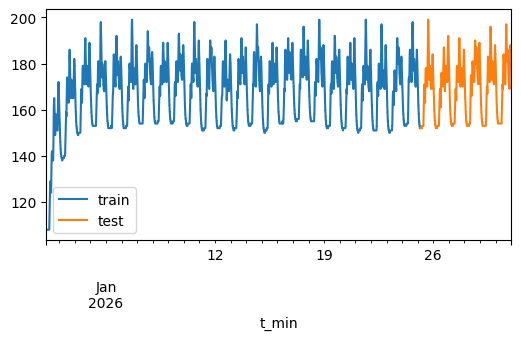

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 3))
y_train.plot(ax=ax, label='train')
y_test.plot(ax=ax, label='test')
ax.legend()

In [12]:
FORECAST_STEPS = 6   # 30-minutos horizonte
SEED = 123
 
forecaster = ForecasterDirect(
    estimator=XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
    ),
    steps=FORECAST_STEPS,
    lags=6,                   # ultimos 30 min de glucemias
    n_jobs="auto",             
)
forecaster.fit(y=y_train,exog=x_train)
forecaster

================ 
ForecasterDirect 
================ 
Estimator: XGBRegressor 
Lags: [1 2 3 4 5 6] 
Window features: None 
Window size: 6 
Maximum steps to predict: 6 
Series name: gluc_mg 
Exogenous included: True 
Exogenous names: 
    meal_carb, snack_carb, bolus_insulin, basal_insulin, running_speed, basal_-24h,
    meal_carb_-20m, meal_carb_-40m, meal_carb_-60m, meal_carb_-80m,
    meal_carb_-100m, meal_carb_-120m, meal_carb_-140m, meal_carb_-160m,
    meal_carb_-180m, meal_carb_-200m, meal_carb_-220m, meal_carb_-240m,
    snack_carb_-20m, snack_carb_-40m, snack_carb_-60m, snack_carb_-80m,
    snack_carb_-100m, snack_carb_-120m, snack_carb_-140m, ..., snack_carb_-240m,
    bolus_insulin_-20m, bolus_insulin_-40m, bolus_insulin_-60m,
    bolus_insulin_-80m, bolus_insulin_-100m, bolus_insulin_-120m,
    bolus_insulin_-140m, bolus_insulin_-160m, bolus_insulin_-180m,
    bolus_insulin_-200m, bolus_insulin_-220m, bolus_insulin_-240m,
    running_speed_-20m, running_speed_-40m, running_speed_-60m,
    running_speed_-80m, running_speed_-100m, running_speed_-120m,
    running_speed_-140m, running_speed_-160m, running_speed_-180m,
    running_speed_-200m, running_speed_-220m, running_speed_-240m 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2026-01-01 04:00:00'), Timestamp('2026-01-25 04:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <5 * Minutes> 
Estimator parameters: 
    {'objective': 'reg:squarederror', 'base_score': None, 'booster': None,
    'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None,
    'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None,
    'enable_categorical': False, 'eval_metric': None, 'feature_types': None,
    'feature_weights': None, 'gamma': None, 'grow_policy': None,
    'importance_type': None, 'interaction_constraints': None, 'learning_rate':
    0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None,
    'max_delta_step': None, 'max_depth': 5, 'max_leaves': None,
    'min_child_weight': None, 'missing': nan, 'monotone_constraints': None,
    'multi_strategy': None, 'n_estimators': 200, 'n_jobs': None,
    'num_parallel_tree': None, 'random_state': 123, 'reg_alpha': None,
    'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None,
    'subsample': 0.8, 'tree_method': None, 'validate_parameters': None,
    'verbosity': None} 
fit_kwargs: {} 
Creation date: 2026-05-03 23:56:09 
Last fit date: 2026-05-03 23:56:16 
Skforecast version: 0.21.0 
Python version: 3.12.12 
Forecaster id: None

In [13]:
predictions = forecaster.predict(exog= x_test)
display(predictions.head())
display(y_test.head())

2026-01-25 04:05:00    151.982483
2026-01-25 04:10:00    151.975555
2026-01-25 04:15:00    151.986877
2026-01-25 04:20:00    151.982025
2026-01-25 04:25:00    151.972015
Freq: 5min, Name: pred, dtype: float64

t_min
2026-01-25 04:05:00    152.0
2026-01-25 04:10:00    152.0
2026-01-25 04:15:00    152.0
2026-01-25 04:20:00    152.0
2026-01-25 04:25:00    152.0
Freq: 5min, Name: gluc_mg, dtype: float64

In [14]:
forecaster.get_feature_importances(step=3)


,feature,importance
0,lag_1,0.325469
2,lag_3,0.214712
1,lag_2,0.212592
3,lag_4,0.130947
5,lag_6,0.011810
44,bolus_insulin_-180m,0.011369
4,lag_5,0.009193
15,meal_carb_-80m,0.008751
16,meal_carb_-100m,0.008058
25,snack_carb_-40m,0.006197


## Clarke Error Grid

In [15]:
def clasificar_zona_clarke(ref: float, pred: float) -> str:
    """
    Clasifica un par (valor_real, predicción) en una de las cinco
    zonas del Clarke Error Grid (A, B, C, D, E).
 
    La clasificación sigue las ecuaciones originales de Clarke et al.
    (Diabetes Care, 1987) con las correcciones de Kovatchev et al.
 
    Las zonas se definen por regiones en el espacio 2D donde el eje X
    es el valor real de glucosa y el eje Y es la predicción:
 
    Zona A: Error clínicamente aceptable.
      - Ambos valores < 70 mg/dL (zona de hipoglucemia concordante), O
      - La predicción está dentro del ±20% del valor real.
      El tratamiento basado en esta predicción sería correcto.
 
    Zona E: Error clínicamente peligroso (opuesto al correcto).
      - Real < 70 y predicción > 180: predice hiperglucemia cuando
        hay hipoglucemia → se administraría insulina cuando no procede.
      - Real > 180 y predicción < 70: predice hipoglucemia cuando
        hay hiperglucemia → se darían carbohidratos cuando no procede.
 
    Zona D: Error grave por omisión (fallo en detectar extremos).
      - Real < 70 y predicción entre 70-180: no detecta hipoglucemia.
      - Real > 240 y predicción entre 70-180: no detecta hiperglucemia.
 
    Zona C: Corrección innecesaria.
      - Real entre 130-180 y predicción > 180+((pred-180)*0.8): predice
        hiperglucemia leve cuando el valor es aceptable.
      - Real entre 70-130 y predicción < 70-((70-pred)*0.8): predice
        hipoglucemia cuando el valor es aceptable.
 
    Zona B: Todo lo demás — error no peligroso clínicamente.
 
    Parámetros
    ----------
    ref : float
        Valor real de glucosa en sangre (mg/dL).
    pred : float
        Valor predicho de glucosa en sangre (mg/dL).
 
    Retorna
    -------
    str : 'A', 'B', 'C', 'D' o 'E'
    """
    # ── Zona A ───────────────────────────────────────────────────
    if (ref < 70 and pred < 70) or (abs(pred - ref) / max(ref, 1e-6) <= 0.20):
        return "A"
 
    # ── Zona E ───────────────────────────────────────────────────
    if (ref < 70 and pred > 180) or (ref > 180 and pred < 70):
        return "E"
 
    # ── Zona D ───────────────────────────────────────────────────
    if (ref < 70 and 70 <= pred <= 180) or (ref > 240 and 70 <= pred <= 180):
        return "D"
 
    # ── Zona C ───────────────────────────────────────────────────
    # Subzona C superior: predice hiperglucemia cuando real está en rango
    if 130 <= ref <= 180 and pred > ref + (ref - 130) / (180 - 130) * 50 + 50:
        return "C"
    # Subzona C inferior: predice hipoglucemia cuando real está en rango
    if 70 <= ref <= 130 and pred < ref - (ref - 70) / (130 - 70) * 50 - 20:
        return "C"
 
    # ── Zona B ───────────────────────────────────────────────────
    return "B"

def clarke_error_grid(
    y_real: np.ndarray,
    y_pred: np.ndarray,
) -> pd.DataFrame:
    """
    Clasifica todos los pares (real, predicción) en zonas Clarke y
    devuelve un DataFrame con la clasificación y estadísticas.
 
    Parámetros
    ----------
    y_real : np.ndarray
        Array de valores reales de glucosa (mg/dL).
    y_pred : np.ndarray
        Array de predicciones de glucosa (mg/dL).
 
    Retorna
    -------
    pd.DataFrame con columnas: real, pred, zona.
    """
    y_real = np.asarray(y_real).flatten()
    y_pred = np.asarray(y_pred).flatten()
 
    zonas = [clasificar_zona_clarke(r, p) for r, p in zip(y_real, y_pred)]
 
    return pd.DataFrame({
        "real": y_real,
        "pred": y_pred,
        "zona": zonas,
    })


def resumen_clarke(df_clarke: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula el porcentaje de predicciones en cada zona Clarke.
 
    Desde el punto de vista clínico:
      - Zona A + B: predicciones clínicamente aceptables 
      - Zona C:     correcciones innecesarias 
      - Zona D:     fallos en detectar extremos 
      - Zona E:     predicciones peligrosas 
 
    Parámetros
    ----------
    df_clarke : pd.DataFrame
        Resultado de clarke_error_grid().
 
    Retorna
    -------
    pd.DataFrame con zonas, conteos y porcentajes.
    """
    total   = len(df_clarke)
    conteos = df_clarke["zona"].value_counts().reindex(["A", "B", "C", "D", "E"], fill_value=0)
    pcts    = (conteos / total * 100).round(2)
 
    resumen = pd.DataFrame({
        "zona":       conteos.index,
        "n":          conteos.values,
        "porcentaje": pcts.values,
    })
 
    return resumen

# ═══════════════════════════════════════════════════════════════════
# VISUALIZACIÓN
# ═══════════════════════════════════════════════════════════════════
 
# Colores clínicamente intuitivos para cada zona
COLORES_ZONA = {
    "A": "#2ecc71",   # Verde — seguro
    "B": "#f39c12",   # Naranja — aceptable
    "C": "#e67e22",   # Naranja oscuro — precaución
    "D": "#e74c3c",   # Rojo — peligroso
    "E": "#8e44ad",   # Púrpura — muy peligroso
}
 
 
def _dibujar_regiones_clarke(ax: plt.Axes, max_val: float = 400) -> None:
    """
    Dibuja las líneas de frontera del Clarke Error Grid sobre un eje.
 
    Las fronteras siguen la especificación original de Clarke et al.:
      - Línea de identidad (predicción = real)
      - Bandas del ±20% (fronteras de la zona A)
      - Fronteras de las zonas C, D y E definidas por segmentos lineales
 
    Este es un método auxiliar — no se llama directamente.
 
    Parámetros
    ----------
    ax : plt.Axes
        Eje de matplotlib sobre el que dibujar.
    max_val : float
        Valor máximo del eje (mg/dL). Default 400.
    """
    lw = 0.8   # grosor de líneas de frontera
 
    # Línea de identidad
    ax.plot([0, max_val], [0, max_val], "k--", lw=lw, alpha=0.5, zorder=1)
 
    # Fronteras zona A: ±20%
    ax.plot([0, max_val], [0, max_val * 1.20], color="gray", lw=lw, ls="--", alpha=0.4)
    ax.plot([0, max_val], [0, max_val * 0.80], color="gray", lw=lw, ls="--", alpha=0.4)
 
    # ── Fronteras zona E (superior izquierda y inferior derecha) ──
    # E superior: real < 70, pred > 180
    ax.plot([0, 70],  [180, 180], "k-", lw=lw)
    ax.plot([70, 70], [180, max_val], "k-", lw=lw)
    # E inferior: real > 180, pred < 70
    ax.plot([180, 180], [0, 70], "k-", lw=lw)
    ax.plot([180, max_val], [70, 70], "k-", lw=lw)
 
    # ── Fronteras zona D ──
    # D superior: real < 70, pred 70-180
    ax.plot([70, 70], [70, 180], "k-", lw=lw)
    # D inferior: real > 240, pred 70-180
    ax.plot([240, 240], [70, 180], "k-", lw=lw)
    ax.plot([240, max_val], [180, 180], "k-", lw=lw)
 
    # ── Fronteras zona C ──
    # C superior (real 130-180, pred exageradamente alta)
    ax.plot([130, 180], [180, 230], "k-", lw=lw)
    ax.plot([180, 180], [230, max_val], "k-", lw=lw)
    # C inferior (real 70-130, pred exageradamente baja)
    ax.plot([70, 130],  [50, 70], "k-", lw=lw)
    ax.plot([70, 70],   [0, 50], "k-", lw=lw)
 
    # Etiquetas de zona en posiciones representativas
    etiquetas = {
        "A": (200, 200), "B": (340, 160), "B ": (160, 340),
        "C": (160, 380), "C ": (400, 130),
        "D": (40, 150),  "D ": (300, 130),
        "E": (40, 350),  "E ": (350, 40),
    }
    for label, (x, y) in etiquetas.items():
        if x <= max_val and y <= max_val:
            ax.text(x, y, label.strip(), fontsize=11, fontweight="bold",
                    color="gray", alpha=0.6, ha="center", va="center")



def plot_clarke_error_grid(
    df_clarke: pd.DataFrame,
    titulo: str = "Clarke Error Grid",
    max_val: float = 400,
    ax: plt.Axes = None,
) -> plt.Axes:
    """
    Genera el gráfico del Clarke Error Grid con los puntos coloreados
    por zona clínica y las fronteras de cada región.
 
    Cada punto representa un par (glucosa real, glucosa predicha).
    El color indica la zona clínica: verde=A, naranja=B, etc.
 
    Parámetros
    ----------
    df_clarke : pd.DataFrame
        Resultado de clarke_error_grid() con columnas real, pred, zona.
    titulo : str
        Título del gráfico.
    max_val : float
        Límite de los ejes en mg/dL. Default 400.
    ax : plt.Axes, opcional
        Eje existente. Si None, se crea una figura nueva.
 
    Retorna
    -------
    plt.Axes con el gráfico generado.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
 
    # Dibujar regiones primero (fondo)
    _dibujar_regiones_clarke(ax, max_val)
 
    # Scatter por zona
    for zona, grupo in df_clarke.groupby("zona"):
        ax.scatter(
            grupo["real"], grupo["pred"],
            c=COLORES_ZONA[zona],
            label=f"Zona {zona} ({len(grupo)})",
            alpha=0.5,
            s=8,
            zorder=2,
        )
 
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.set_xlabel("Glucosa real (mg/dL)", fontsize=12)
    ax.set_ylabel("Glucosa predicha (mg/dL)", fontsize=12)
    ax.set_title(titulo, fontsize=13, fontweight="bold")
    ax.legend(loc="upper left", fontsize=9, markerscale=2)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.2)
 
    return ax

In [16]:
def evaluar_clarke_backtesting(
    y: pd.Series,
    predictions: pd.DataFrame,
    horizonte: str,
    patient_id: int,
    sim_id: int,
    mostrar_graficos: bool = True,
    guardar_graficos: bool = False,
) -> dict:
    """
    Calcula y visualiza el Clarke Error Grid para las predicciones
    de un único caso (paciente × simulación × horizonte).
 
    Alinea temporalmente las predicciones con los valores reales,
    calcula las zonas Clarke para cada par y genera gráfico:
      1. Clarke Error Grid (scatter en espacio 2D)

 
    Parámetros
    ----------
    y : pd.Series
        Serie completa de glucosa (train + test).
    predictions : pd.DataFrame
        Predicciones del backtesting (columna 'pred', índice temporal).
    horizonte : str
        Nombre del horizonte ('15min' o '30min') — usado en títulos.
    patient_id : int
        ID del paciente — usado en títulos y nombres de archivo.
    sim_id : int
        ID de la simulación — usado en títulos y nombres de archivo.
    mostrar_graficos : bool
        Si True, muestra los gráficos en pantalla (plt.show()).
    guardar_graficos : bool
        Si True, guarda los gráficos como PNG.
 
    Retorna
    -------
    dict con:
        'df_clarke'   : DataFrame con clasificación zona por punto
        'resumen'     : DataFrame con porcentajes por zona
        'pct_A'       : % zona A
        'pct_AB'      : % zonas A+B (métrica clínica principal)
        'pct_DE'      : % zonas D+E (predicciones peligrosas)
    """
    # Alinear predicciones con valores reales
    y_test    = y.loc[predictions.index]
    y_real    = y_test.values
    y_pred    = predictions["pred"].values
 
    # Clasificar en zonas Clarke
    df_clarke = clarke_error_grid(y_real, y_pred)
    resumen   = resumen_clarke(df_clarke)
 
    pct_A  = resumen.loc[resumen["zona"] == "A", "porcentaje"].values[0]
    pct_AB = resumen.loc[resumen["zona"].isin(["A", "B"]), "porcentaje"].sum()
    pct_DE = resumen.loc[resumen["zona"].isin(["D", "E"]), "porcentaje"].sum()
 
    titulo_base = f"Paciente {patient_id:02d} | Sim {sim_id} | {horizonte}"
 
    if mostrar_graficos or guardar_graficos:
        # ── Figura 1: Clarke Error Grid + barras de zonas ────────
        fig1, (ax_grid, ax_bar) = plt.subplots(1, 2, figsize=(14, 6))
        plot_clarke_error_grid(df_clarke, titulo=f"CEG — {titulo_base}", ax=ax_grid)
        # plot_resumen_zonas(resumen, titulo=f"Distribución zonas — {titulo_base}", ax=ax_bar)
        plt.tight_layout()
 
        if guardar_graficos:
            fig1.savefig(
                f"clarke_grid_p{patient_id:02d}_s{sim_id}_{horizonte}.png",
                dpi=150, bbox_inches="tight",
            )
        if mostrar_graficos:
            plt.show()
        plt.close(fig1)
 
        
 
    return {
        "df_clarke": df_clarke,
        "resumen":   resumen,
        "pct_A":     pct_A,
        "pct_AB":    pct_AB,
        "pct_DE":    pct_DE,
    }

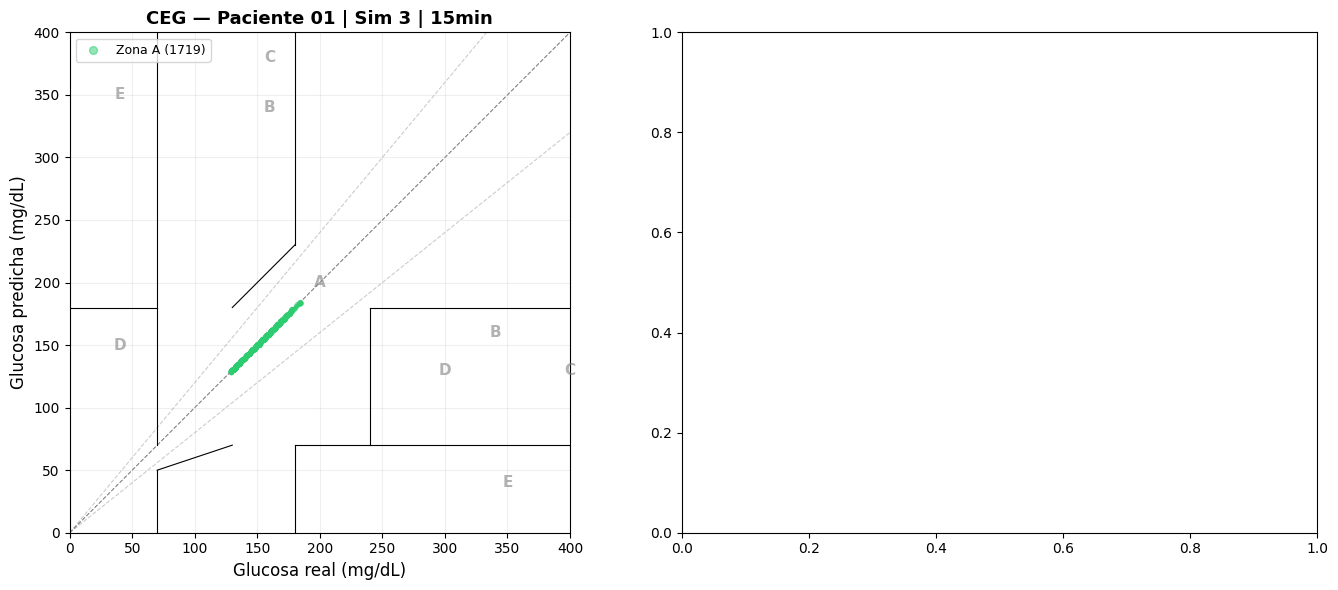

{'df_clarke':        real        pred zona
 0     153.0  152.956757    A
 1     152.0  151.999313    A
 2     151.0  150.992294    A
 3     150.0  149.995010    A
 4     149.0  148.945694    A
 ...     ...         ...  ...
 1714  160.0  160.004379    A
 1715  159.0  159.001358    A
 1716  159.0  158.989288    A
 1717  158.0  157.990204    A
 1718  157.0  156.994202    A
 
 [1719 rows x 3 columns],
 'resumen':   zona     n  porcentaje
 0    A  1719       100.0
 1    B     0         0.0
 2    C     0         0.0
 3    D     0         0.0
 4    E     0         0.0,
 'pct_A': 100.0,
 'pct_AB': 100.0,
 'pct_DE': 0.0}

In [28]:
r_prueba = RESULTS_DIR / f"xgb_15min_p01_s3.pkl"
with open(r_prueba, "rb") as f:
    pa = pickle.load(f)

pa['predictions']
evaluar_clarke_backtesting(ref_y,pa['predictions'],'15min',1,3)

## Skforecast sobre todos los datos

In [17]:
# Índice temporal 
for s in range(1,7):
    for p in range(20):
        datos[s][f'p_{p}'] = indexar_temp(datos[s][f'p_{p}'])

In [3]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from skforecast.direct import ForecasterDirect
from skforecast.model_selection import (
    backtesting_forecaster,
    bayesian_search_forecaster,
    TimeSeriesFold,
    OneStepAheadFold,
)

# ═══════════════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════════════
 
HORIZONTES = {
    "15min": 3,   # 3 steps × 5 min = 15 min ahead
    "30min": 6,   # 6 steps × 5 min = 30 min ahead
}
 
TRAIN_RATIO = 0.80                             # 80% train / 20% test
N_TRIALS    = 50                               # Bayesian search iterations
RANDOM_STATE = 42
 
# Which patient/simulation to use for hyperparameter optimization.
# Using a single reference case avoids overfitting hyperparameters
# to the full population while keeping tuning computationally feasible.
REFERENCE_PATIENT = 1
REFERENCE_SIM     = 3
N_PATIENTS = 20
N_SIMS     = 6
RESULTS_DIR = Path("Boost_resultados")
RESULTS_DIR.mkdir(exist_ok=True)
BEST_PARAMS_PATH = RESULTS_DIR / "XG_mejores_parametros.pkl"

# ═══════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ═══════════════════════════════════════════════════════════════════

def make_forecaster(steps: int, params: dict) -> ForecasterDirect:
    """
    Instantiates a ForecasterDirect with XGBoost using a given
    set of hyperparameters.
 
    ForecasterDirect trains ONE independent XGBoost model per forecast
    step. For a 6-step (30-min) horizon it trains 6 models: one to
    predict t+5, one for t+10, ..., one for t+30. This avoids the
    error-propagation problem of recursive strategies (where a wrong
    prediction at t+5 contaminates t+10, etc.), at the cost of
    training more models.
 
    Parameters
    ----------
    steps : int
        Forecast horizon in number of 5-min steps.
    params : dict
        Hyperparameter dict as returned by bayesian_search_forecaster.
        Must contain 'lags' plus all XGBoost parameters.
 
    Returns
    -------
    ForecasterDirect
        Untrained forecaster ready to be passed to backtesting or fit().
    """
    lags = params.pop("lags")   # lags is a ForecasterDirect param, not XGBoost
    return ForecasterDirect(
        estimator=XGBRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1),
        steps=steps,
        lags=lags,
        n_jobs="auto",   # parallelise training across the `steps` models
    )

def optimize_hyperparameters(
    y_train: pd.Series,
    exog_train: pd.DataFrame,
    steps: int,
    n_trials: int = N_TRIALS,
) -> dict:
    """
    Runs Bayesian hyperparameter search using Optuna on a single
    reference training set and returns the best parameter dict.
 
    We use OneStepAheadFold here instead of TimeSeriesFold for speed.
    OneStepAheadFold fits the model once and evaluates it by sliding
    a one-step-ahead prediction window across the validation portion.
    It is much faster than TimeSeriesFold (which re-trains at every
    fold) and is accurate enough for comparing hyperparameter
    combinations against each other, even if the absolute metric
    value is slightly optimistic.
 
    The search space covers:
      - lags          : how many past glucose readings to use (30–180 min)
      - n_estimators  : number of trees
      - max_depth     : tree depth (controls model complexity)
      - learning_rate : shrinkage — lower = slower but more robust
      - subsample     : fraction of rows sampled per tree (prevents overfitting)
      - colsample_bytree : fraction of features sampled per tree
      - min_child_weight : minimum samples in a leaf (regularisation)
      - reg_alpha     : L1 regularisation on weights
      - reg_lambda    : L2 regularisation on weights
 
    Parameters
    ----------
    y_train : pd.Series
        Target training series from the reference dataset.
    exog_train : pd.DataFrame
        Exogenous features for the training period.
    steps : int
        Forecast horizon (passed to ForecasterDirect).
    n_trials : int
        Number of Optuna trials. More trials = better search but slower.
 
    Returns
    -------
    dict
        Best hyperparameters found (including 'lags').
    """
    forecaster = ForecasterDirect(
        estimator=XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        steps=steps,
        lags=12,
        n_jobs="auto",
    )
 
    # OneStepAheadFold: fast inner CV using 80% of the training data
    # as the inner training set and the remaining 20% as validation.
    cv_search = OneStepAheadFold(
        initial_train_size=int(len(y_train) * 0.80),
    )
 
    def search_space(trial):
        return {
            "lags":             trial.suggest_categorical("lags", [3, 6, 12, 24, 36]),
            "n_estimators":     trial.suggest_int("n_estimators",     50,   500),
            "max_depth":        trial.suggest_int("max_depth",          3,    10),
            "learning_rate":    trial.suggest_float("learning_rate", 0.01,   0.3, log=True),
            "subsample":        trial.suggest_float("subsample",       0.6,   1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree",0.6,   1.0),
            "min_child_weight": trial.suggest_int("min_child_weight",    1,    20),
            "reg_alpha":        trial.suggest_float("reg_alpha",      1e-4,  10.0, log=True),
            "reg_lambda":       trial.suggest_float("reg_lambda",     1e-4,  10.0, log=True),
        }
 
    # bayesian_search_forecaster uses Optuna's TPE sampler to
    # intelligently explore the search space, concentrating trials
    # in regions that previously yielded low MAE. return_best=True
    # updates the forecaster in-place with the winning configuration.
    results, _ = bayesian_search_forecaster(
        forecaster=forecaster,
        y=y_train,
        exog=exog_train,
        cv=cv_search,
        search_space=search_space,
        metric="mean_absolute_error",
        n_trials=n_trials,
        return_best=True,
        n_jobs="auto",
        show_progress=True,
        random_state=RANDOM_STATE,
    )
 
    best_params = results.iloc[0]["params"]
    best_params["lags"] = results.iloc[0]["lags"]
    print(f"  Best MAE (search): {results.iloc[0]['mean_absolute_error']:.2f} mg/dL")
    print(f"  Best params: {best_params}")
    return best_params
 
def run_backtesting(
    y: pd.Series,
    exog: pd.DataFrame,
    steps: int,
    best_params: dict,
    train_ratio: float = TRAIN_RATIO,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Runs backtesting with refit and fixed training size on a single
    dataset using pre-optimized hyperparameters.
 
    TimeSeriesFold with refit=True and fixed_train_size=True implements
    a SLIDING WINDOW evaluation:
 
        |←── fixed train ──→|← test fold 1 →|
                |←── fixed train ──→|← test fold 2 →|
                        |←── fixed train ──→|← test fold 3 →|
 
    At each fold:
      1. The model is retrained from scratch on the current training window.
      2. It predicts the next `steps` values.
      3. The window slides forward by `steps` rows.
 
    This is the most realistic evaluation strategy because it mimics
    a deployed system that periodically retrains on recent data,
    matching the non-stationary nature of glucose dynamics (sensor
    drift, changes in patient behaviour, etc.).
 
    fixed_train_size=True (sliding) vs False (expanding):
      - Sliding: always trains on the same amount of data. Better when
        older data may be less relevant (e.g. patient lifestyle changes).
      - Expanding: trains on all available history. Better when more
        data always helps and the process is stationary.
    For CGM data, sliding is the safer choice.
 
    Parameters
    ----------
    y : pd.Series
        Full target series (train + test).
    exog : pd.DataFrame
        Full exogenous features (train + test).
    steps : int
        Forecast horizon in 5-min steps.
    best_params : dict
        Hyperparameters from optimize_hyperparameters().
    train_ratio : float
        Fraction of data used as the initial training window.
 
    Returns
    -------
    metrics : pd.DataFrame
        MAE, RMSE and MAPE for this dataset.
    predictions : pd.DataFrame
        Out-of-sample predictions with a 'pred' column aligned to y's index.
    """
    initial_train = int(len(y) * train_ratio)
 
    # Re-instantiate with best params (dict is consumed by pop() in
    # make_forecaster so we pass a copy each time)
    forecaster = make_forecaster(steps=steps, params=best_params.copy())
 
    # TimeSeriesFold defines the cross-validation strategy.
    # initial_train_size : size of the first (and every subsequent)
    #                      training window in rows.
    # refit=True         : retrain the model at the start of every fold.
    # fixed_train_size=True : sliding window — old rows are dropped as
    #                         new ones are added.
    # allow_incomplete_fold : keep the last fold even if it has fewer
    #                         than `steps` rows remaining.
    cv = TimeSeriesFold(
        steps=steps,
        initial_train_size=initial_train,
        refit=True,
        fixed_train_size=True,
        allow_incomplete_fold=True,
        verbose=False,
    )
 
    # backtesting_forecaster orchestrates the full walk-forward loop:
    #   - splits y and exog according to cv
    #   - fits the forecaster on each training fold
    #   - generates predictions on each test fold
    #   - computes the requested metrics across all folds
    # It returns a metrics DataFrame and a predictions DataFrame whose
    # index is aligned with the original y index (test portion only).
    metrics, predictions = backtesting_forecaster(
        forecaster=forecaster,
        y=y,
        exog=exog,
        cv=cv,
        metric=["mean_absolute_error", "mean_squared_error"],
        n_jobs= -1,
        show_progress=True,
        verbose=False,
    )
 
    metrics["RMSE"] = np.sqrt(metrics["mean_squared_error"])
    return metrics, predictions

In [19]:
# ═══════════════════════════════════════════════════════════════════
# MAIN PIPELINE
# ═══════════════════════════════════════════════════════════════════
 
# ── Step 1: Load and prepare all datasets ───────────────────────────
# Replace this block with your actual data loading logic.
# Expected structure: datasets[patient_id][sim_id] = prepared DataFrame
 
N_PATIENTS = 20
N_SIMS     = 6
RESULTS_DIR = Path("Boost_resultados")
RESULTS_DIR.mkdir(exist_ok=True)
BEST_PARAMS_PATH = RESULTS_DIR / "XG_mejores_parametros.pkl"


 
# ── Step 2: Hyperparameter optimization (reference dataset only) ────
 
print("=" * 60)
print("HYPERPARAMETER OPTIMIZATION")
print(f"Reference: patient {REFERENCE_PATIENT}, simulation {REFERENCE_SIM}")
print("=" * 60)
 
ref_df = datos[REFERENCE_SIM][f'p_{REFERENCE_PATIENT}']
ref_y, ref_exog = crear_features(ref_df)
 
# Use only the training portion of the reference dataset for tuning
ref_train_size = int(len(ref_y) * TRAIN_RATIO)
ref_y_train    = ref_y.iloc[:ref_train_size]
ref_exog_train = ref_exog.iloc[:ref_train_size]
 
best_params = {}
for horizon_name, steps in HORIZONTES.items():
    print(f"\n── Optimizing for {horizon_name} horizon ({steps} steps) ──")
    best_params[horizon_name] = optimize_hyperparameters(
        y_train=ref_y_train,
        exog_train=ref_exog_train,
        steps=steps,
    )
 
print("\nBest hyperparameters per horizon:")
for horizon_name, params in best_params.items():
    print(f"  {horizon_name}: {params}")

# with open(BEST_PARAMS_PATH, "wb") as f:
#     pickle.dump(best_params, f, protocol=pickle.HIGHEST_PROTOCOL)
 
# print(f"✓ Hiperparámetros guardados en {BEST_PARAMS_PATH}")

HYPERPARAMETER OPTIMIZATION
Reference: patient 1, simulation 3

── Optimizing for 15min horizon (3 steps) ──


╭─────────────────────────── OneStepAheadValidationWarning ────────────────────────────╮
│ One-step-ahead predictions are used for faster model comparison, but they may not    │
│ fully represent multi-step prediction performance. It is recommended to backtest the │
│ final model for a more accurate multi-step performance estimate.                     │
│                                                                                      │
│ Category : skforecast.exceptions.OneStepAheadValidationWarning                       │
│ Location :                                                                           │
│ c:\Users\Usuario\anaconda3\envs\tfg2\Lib\site-packages\skforecast\model_selection\_u │
│ tils.py:635                                                                          │
│ Suppress : warnings.simplefilter('ignore', category=OneStepAheadValidationWarning)   │
╰──────────────────────────────────────────────────────────────────────────────────────╯

  0%|          | 0/50 [00:00<?, ?it/s]

  Best MAE (search): 0.10 mg/dL
  Best params: {'n_estimators': 301, 'max_depth': 9, 'learning_rate': 0.0400030530899276, 'subsample': 0.9813961717709769, 'colsample_bytree': 0.9618381090520217, 'min_child_weight': 1, 'reg_alpha': 0.004255849951464825, 'reg_lambda': 0.0011817507356566852, 'lags': array([1, 2, 3])}

── Optimizing for 30min horizon (6 steps) ──


╭─────────────────────────── OneStepAheadValidationWarning ────────────────────────────╮
│ One-step-ahead predictions are used for faster model comparison, but they may not    │
│ fully represent multi-step prediction performance. It is recommended to backtest the │
│ final model for a more accurate multi-step performance estimate.                     │
│                                                                                      │
│ Category : skforecast.exceptions.OneStepAheadValidationWarning                       │
│ Location :                                                                           │
│ c:\Users\Usuario\anaconda3\envs\tfg2\Lib\site-packages\skforecast\model_selection\_u │
│ tils.py:635                                                                          │
│ Suppress : warnings.simplefilter('ignore', category=OneStepAheadValidationWarning)   │
╰──────────────────────────────────────────────────────────────────────────────────────╯

  0%|          | 0/50 [00:00<?, ?it/s]

  Best MAE (search): 0.10 mg/dL
  Best params: {'n_estimators': 301, 'max_depth': 9, 'learning_rate': 0.0400030530899276, 'subsample': 0.9813961717709769, 'colsample_bytree': 0.9618381090520217, 'min_child_weight': 1, 'reg_alpha': 0.004255849951464825, 'reg_lambda': 0.0011817507356566852, 'lags': array([1, 2, 3])}

Best hyperparameters per horizon:
  15min: {'n_estimators': 301, 'max_depth': 9, 'learning_rate': 0.0400030530899276, 'subsample': 0.9813961717709769, 'colsample_bytree': 0.9618381090520217, 'min_child_weight': 1, 'reg_alpha': 0.004255849951464825, 'reg_lambda': 0.0011817507356566852, 'lags': array([1, 2, 3])}
  30min: {'n_estimators': 301, 'max_depth': 9, 'learning_rate': 0.0400030530899276, 'subsample': 0.9813961717709769, 'colsample_bytree': 0.9618381090520217, 'min_child_weight': 1, 'reg_alpha': 0.004255849951464825, 'reg_lambda': 0.0011817507356566852, 'lags': array([1, 2, 3])}


In [ ]:
 # ── Step 3: Backtesting on all 120 datasets ─────────────────────────
# For each horizon, we run backtesting on every patient/simulation
# combination using the fixed best hyperparameters from step 2.
# Results are stored in a list of dicts for easy conversion to DataFrame.
 
import warnings


print("\n" + "=" * 60)
print("BACKTESTING")
print("=" * 60)
 
# ── PARÁMETRO A CAMBIAR EN CADA EJECUCIÓN ────────────────────────────
SIM_ID_ACTUAL = 6

# Cargar hiperparámetros desde disco
with open(BEST_PARAMS_PATH, "rb") as f:
    best_params = pickle.load(f)
print(f"✓ Hiperparámetros cargados desde {BEST_PARAMS_PATH}")

# Comprobar qué casos de esta simulación ya están procesados
ya_hechos = [
    (h, p)
    for h in HORIZONTES
    for p in range(N_PATIENTS)
    if (RESULTS_DIR / f"xgb_{h}_p{p:02d}_s{SIM_ID_ACTUAL}.pkl").exists()
]
 
for horizon_name, steps in HORIZONTES.items():
    print(f"\n── Horizon: {horizon_name} ──")
    params = best_params[horizon_name]

    for patient_id in range(N_PATIENTS):
 
        ruta_pkl = RESULTS_DIR / f"xgb_{horizon_name}_p{patient_id:02d}_s{SIM_ID_ACTUAL}.pkl"
 
        # Saltar si ya está procesado
        if ruta_pkl.exists():
            print(f"  [SKIP] Paciente {patient_id:02d} — ya procesado")
            continue    
        print(f"  [RUN]  Paciente {patient_id:02d}...", end=" ", flush=True)
        
        try:
            df = datos[SIM_ID_ACTUAL][f'p_{patient_id}']
            y, exog = crear_features(df)
 
            metrics, predictions = run_backtesting(
                y=y,
                exog=exog,
                steps=steps,
                best_params=params,
            )
 
            mae  = metrics["mean_absolute_error"].values[0]
            rmse = metrics["RMSE"].values[0]

            y_test    = y.loc[predictions.index]
            df_clarke = clarke_error_grid(y_test.values, predictions["pred"].values)
            resumen   = resumen_clarke(df_clarke)
 
            pct_A  = float(resumen.loc[resumen["zona"] == "A",          "porcentaje"].values[0])
            pct_AB = float(resumen.loc[resumen["zona"].isin(["A","B"]), "porcentaje"].sum())
            pct_DE = float(resumen.loc[resumen["zona"].isin(["D","E"]), "porcentaje"].sum())
 
            resultado = {
                "modelo":         "XGBoost",
                "horizonte":      horizon_name,
                "paciente":       patient_id,
                "simulacion":     SIM_ID_ACTUAL,
                "MAE":            mae,
                "RMSE":           rmse,
                "pct_A":          pct_A,
                "pct_AB":         pct_AB,
                "pct_DE":         pct_DE,
                "predictions":    predictions,
                "df_clarke":      df_clarke,
                "resumen_clarke": resumen,
            }
 
            # Escritura atómica: .tmp → .pkl para evitar archivos corruptos
            ruta_tmp = ruta_pkl.with_suffix(".tmp")
            with open(ruta_tmp, "wb") as f:
                pickle.dump(resultado, f, protocol=pickle.HIGHEST_PROTOCOL)
            ruta_tmp.rename(ruta_pkl)
 
            print(
                f"MAE={mae:.2f} mg/dL | RMSE={rmse:.2f} mg/dL | "
                f"A={pct_A:.1f}% | A+B={pct_AB:.1f}% | D+E={pct_DE:.1f}%"
            )
 
        except Exception as e:
            print(f"ERROR: {e}")
            warnings.warn(f"Fallo en p{patient_id:02d}_s{SIM_ID_ACTUAL}_{horizon_name}: {e}")
 
print(f"\n✓ Simulación {SIM_ID_ACTUAL} completada")

In [5]:
# ── Step 4: Aggregate results ────────────────────────────────────────
 
todos_resultados = []
for ruta in sorted(RESULTS_DIR.glob("xgb_*.pkl")):
    with open(ruta, "rb") as f:
        todos_resultados.append(pickle.load(f))
 
total_esperado = len(HORIZONTES) * N_PATIENTS * N_SIMS
print(f"Checkpoints cargados: {len(todos_resultados)} / {total_esperado}")
if len(todos_resultados) < total_esperado:
    print(f"⚠ Faltan {total_esperado - len(todos_resultados)} casos — resumen parcial")
 
COLS_METRICAS = [
    "modelo", "horizonte", "paciente", "simulacion",
    "MAE", "RMSE", "pct_A", "pct_AB", "pct_DE",
]
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k in COLS_METRICAS}
    for r in todos_resultados
])
 
print("\n" + "=" * 60)
print("RESUMEN GLOBAL — Media ± Desv. Típica")
print("=" * 60)
print(
    results_df
    .groupby("horizonte")[["MAE", "RMSE", "pct_A", "pct_AB", "pct_DE"]]
    .agg(["mean", "std"]).round(4).to_string()
)
 
print("\n── Por paciente (media sobre simulaciones) ──")
print(
    results_df
    .groupby(["horizonte", "paciente"])[["MAE", "RMSE", "pct_AB", "pct_DE"]]
    .mean().round(4).to_string()
)
 
print("\n── Por simulación (media sobre pacientes) ──")
print(
    results_df
    .groupby(["horizonte", "simulacion"])[["MAE", "RMSE", "pct_AB", "pct_DE"]]
    .mean().round(4).to_string()
)
 
results_df.to_csv(RESULTS_DIR / "xgboost_results.csv", index=False)
print(f"\n✓ Tabla guardada en {RESULTS_DIR / 'xgboost_results.csv'}")

Checkpoints cargados: 240 / 240

RESUMEN GLOBAL — Media ± Desv. Típica
              MAE            RMSE          pct_A      pct_AB      pct_DE     
             mean     std    mean     std   mean  std   mean  std   mean  std
horizonte                                                                    
15min      0.1608  0.0735  0.3527  0.1683  100.0  0.0  100.0  0.0    0.0  0.0
30min      0.1742  0.0870  0.4016  0.2429  100.0  0.0  100.0  0.0    0.0  0.0

── Por paciente (media sobre simulaciones) ──
                       MAE    RMSE  pct_AB  pct_DE
horizonte paciente                                
15min     0         0.1126  0.2673   100.0     0.0
          1         0.1124  0.2620   100.0     0.0
          2         0.2828  0.5198   100.0     0.0
          3         0.1945  0.4079   100.0     0.0
          4         0.2237  0.4732   100.0     0.0
          5         0.0719  0.2180   100.0     0.0
          6         0.1247  0.2681   100.0     0.0
          7         0.1200  0.266

In [ ]:
r_prueba = RESULTS_DIR / f"xgb_15min_p03_s3.pkl"
with open(r_prueba, "rb") as f:
    p = pickle.load(f)

In [37]:
p['df_clarke']

,real,pred,zona
0,200.0,200.078171,A
1,198.0,198.039963,A
2,197.0,197.000824,A
3,195.0,195.474167,A
4,194.0,194.040024,A
...,...,...,...
1714,234.0,233.973251,A
1715,233.0,233.072205,A
1716,231.0,231.187164,A
1717,230.0,230.013855,A


In [21]:
display(metrics.head())
display(predictions.head())
predictions.shape

,mean_absolute_error,mean_squared_error,RMSE
0,0.077746,0.047181,0.217212


,fold,pred
2026-01-25 00:50:00,0,163.990097
2026-01-25 00:55:00,0,163.004700
2026-01-25 01:00:00,0,162.013489
2026-01-25 01:05:00,0,162.003479
2026-01-25 01:10:00,0,161.007935


(1719, 2)

### Librería `shap`. Importancia datos

```python
import shap
import matplotlib.pyplot as plt

# ── Extract one step's model from the forecaster ──────────────────
# ForecasterDirect stores each step's fitted estimator in a dict.
# Keys are 1-indexed integers corresponding to forecast steps.

step_to_explain = 3   # t+5 min (first step)
model = forecaster.estimators_[step_to_explain]

# ── Get the training matrix for that step ─────────────────────────
# create_train_X_y() builds the lagged feature matrix exactly as
# skforecast does internally, so SHAP sees the same features the
# model was actually trained on.
X_train, _ = forecaster.create_train_X_y(y=y_train, exog=x_train)

# ── Compute SHAP values ───────────────────────────────────────────
# TreeExplainer is optimized for tree-based models (XGBoost, LightGBM,
# etc.). It computes exact Shapley values efficiently without sampling.
explainer   = shap.TreeExplainer(model)
shap_values = explainer(X_train)   # returns a shap.Explanation object

# ── Plots ─────────────────────────────────────────────────────────

# 1. Beeswarm — shows distribution of SHAP values per feature.
#    Each dot is one training sample. Color = feature value (red=high).
#    Features are sorted by mean |SHAP| importance top to bottom.
shap.plots.beeswarm(shap_values, max_display=20)

# 2. Bar — mean absolute SHAP value per feature (classic importance).
shap.plots.bar(shap_values, max_display=20)

# 3. Waterfall — explains a single prediction (e.g. the last row).
#    Shows how each feature pushes the prediction above/below the
#    baseline (mean training prediction).
shap.plots.waterfall(shap_values[-1])

```

## ARIMAX / SARIMAX

In [ ]:
import warnings
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose
from skforecast.recursive import ForecasterStats
from skforecast.stats import Sarimax
from skforecast.model_selection import (
    backtesting_stats,
    grid_search_stats,
    TimeSeriesFold,
)
 
 
# ═══════════════════════════════════════════════════════════════════
# CONFIGURACIÓN
# ═══════════════════════════════════════════════════════════════════
 
HORIZONS = {
    "15min": 3,   # 3 pasos × 5 min = 15 min
    "30min": 6,   # 6 pasos × 5 min = 30 min
}
 
# Misma lógica que XGBoost: cada 20 min durante las últimas 4 horas 
TRAIN_RATIO       = 0.80
REFERENCE_PATIENT = 1
REFERENCE_SIM     = 3
N_PATIENTS        = 20
N_SIMS            = 6
 
# Periodo estacional en pasos de 5 min:
#   Ciclo diario  → s = 288  (24h × 12 lecturas/hora) — computacionalmente inviable
#   Ciclo horario → s = 12   (1h × 12 lecturas/hora)  — manejable como aproximación
# Usamos s=12 como compromiso entre realismo y coste computacional.
SEASONAL_PERIOD = 12   # ciclo de 1 hora
 
 
# ═══════════════════════════════════════════════════════════════════
# PASO 1: CONSTRUCCIÓN DE FEATURES (idéntico a XGBoost)
# ═══════════════════════════════════════════════════════════════════

 
# ═══════════════════════════════════════════════════════════════════
# PASO 2: OPTIMIZACIÓN DE HIPERPARÁMETROS
# ═══════════════════════════════════════════════════════════════════
 
def optimize_arimax(
    y_train: pd.Series,
    exog_train: pd.DataFrame,
    steps: int,
    incluir_estacionalidad: bool = False,
) -> dict:
    """
    Búsqueda de hiperparámetros ARIMAX mediante grid search.
 
    Para modelos estadísticos skforecast solo ofrece grid_search_stats
    y random_search_stats — NO existe búsqueda bayesiana para ForecasterStats.
    Solo acepta TimeSeriesFold (no OneStepAheadFold).
 
    Sin estacionalidad → seasonal_order=(0,0,0,0) fijo, solo se busca (p,d,q).
    Con estacionalidad → además se busca sobre (P,D,Q,s) con s=SEASONAL_PERIOD.
      Se mantienen P,Q ∈ {0,1} para evitar sobreparametrización con pocos datos.
 
    Parámetros
    ----------
    y_train : pd.Series
        Serie de glucosa del dataset de referencia (solo entrenamiento).
    exog_train : pd.DataFrame
        Exógenas del periodo de entrenamiento.
    steps : int
        Horizonte de predicción en pasos de 5 min.
    incluir_estacionalidad : bool
        Si True, incluye órdenes estacionales en el grid search.
 
    Retorna
    -------
    dict con los mejores hiperparámetros: order, seasonal_order y mae_busqueda.
    """
    cv_search = TimeSeriesFold(
        steps=steps,
        initial_train_size=int(len(y_train) * 0.80),
        refit=False,
        fixed_train_size=False,
        verbose=False,
    )
 
    orders_base = [
        (1, 0, 0), (2, 0, 0),
        (1, 1, 0), (2, 1, 0),
        (1, 0, 1), (2, 0, 1),
        (1, 1, 1), (2, 1, 1),
        (1, 1, 2), (2, 1, 2),
    ]
 
    if not incluir_estacionalidad:
        param_grid = {
            "order":          orders_base,
            "seasonal_order": [(0, 0, 0, 0)],
        }
        print(f"    Grid: {len(orders_base)} combinaciones ARIMA")
    else:
        seasonal_orders = [
            (1, 0, 0, SEASONAL_PERIOD),
            (0, 0, 1, SEASONAL_PERIOD),
            (1, 0, 1, SEASONAL_PERIOD),
            (1, 1, 0, SEASONAL_PERIOD),
            (0, 1, 1, SEASONAL_PERIOD),
            (1, 1, 1, SEASONAL_PERIOD),
        ]
        param_grid = {
            "order":          orders_base,
            "seasonal_order": seasonal_orders,
        }
        print(f"    Grid: {len(orders_base) * len(seasonal_orders)} combinaciones ARIMA × SARIMA (s={SEASONAL_PERIOD})")
 
    forecaster = ForecasterStats(
        estimator=Sarimax(order=(1, 1, 1), seasonal_order=(0, 0, 0, 0))
    )
 
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        results = grid_search_stats(
            forecaster=forecaster,
            y=y_train,
            exog=exog_train,
            cv=cv_search,
            param_grid=param_grid,
            metric="mean_absolute_error",
            return_best=True,
            n_jobs="auto",
            show_progress=True,
            suppress_warnings=True,
        )
 
    best_order          = results.iloc[0]["order"]
    best_seasonal_order = results.iloc[0]["seasonal_order"]
    best_mae            = results.iloc[0]["mean_absolute_error"]
 
    print(f"    → Mejor orden ARIMA    : {best_order}")
    print(f"    → Mejor orden estacional: {best_seasonal_order}")
    print(f"    → MAE en búsqueda      : {best_mae:.2f} mg/dL")
 
    return {
        "order":          best_order,
        "seasonal_order": best_seasonal_order,
        "mae_busqueda":   best_mae,
    }
 
 
# ═══════════════════════════════════════════════════════════════════
# PASO 3: BACKTESTING
# ═══════════════════════════════════════════════════════════════════
 
def run_backtesting_arimax(
    y: pd.Series,
    exog: pd.DataFrame,
    steps: int,
    best_params: dict,
    train_ratio: float = TRAIN_RATIO,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Ejecuta el backtesting walk-forward para ARIMAX con ventana deslizante.
 
    Usa backtesting_stats (específica para ForecasterStats) con:
      - refit=True + fixed_train_size=True → ventana deslizante
      - freeze_params=True → orden (p,d,q) fijo, coeficientes AR/MA
        se reestiman en cada fold sobre la nueva ventana de datos
      - seasonal_order=(0,0,0,0) siempre — sin componente estacional
 
    Parámetros
    ----------
    y : pd.Series
        Serie completa de glucosa (train + test).
    exog : pd.DataFrame
        Exógenas completas (train + test).
    steps : int
        Horizonte de predicción en pasos de 5 min.
    best_params : dict
        Parámetros ARIMA: {'order': (p,d,q)}. seasonal_order se fija
        internamente a (0,0,0,0).
    train_ratio : float
        Fracción de datos usada como ventana de entrenamiento inicial.
 
    Retorna
    -------
    metrics : pd.DataFrame
        MAE, MSE y RMSE del backtesting.
    predictions : pd.DataFrame
        Predicciones fuera de muestra alineadas con el índice de y.
    """

    initial_train = int(len(y) * train_ratio)
 
    forecaster = ForecasterStats(
        estimator=Sarimax(
            order=best_params["order"],
            seasonal_order=(0,0,0,0),
        )
    )
 
    cv = TimeSeriesFold(
        steps=steps,
        initial_train_size=initial_train,
        refit=True,
        fixed_train_size=True,
        allow_incomplete_fold=True,
        verbose=False,
    )
 
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        metrics, predictions = backtesting_stats(
            forecaster=forecaster,
            y=y,
            exog=exog,
            cv=cv,
            metric=["mean_absolute_error", "mean_squared_error"],
            freeze_params=True,
            show_progress=False,
            suppress_warnings=True,
            verbose=False,
        )
 
    metrics["RMSE"] = np.sqrt(metrics["mean_squared_error"])
    return metrics, predictions

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# PIPELINE PRINCIPAL
# ═══════════════════════════════════════════════════════════════════
 
# ── Dataset de referencia ────────────────────────────────────────────
ref_df = datos[REFERENCE_SIM][f'p_{REFERENCE_PATIENT}']
ref_y, ref_exog = crear_features(ref_df)
 
ref_train_size = int(len(ref_y) * TRAIN_RATIO)
ref_y_train    = ref_y.iloc[:ref_train_size]
ref_exog_train = ref_exog.iloc[:ref_train_size]
 

 
 
# ── Optimización comparando ambos casos ───────────────────────────
# Se evalúan siempre los dos casos para que la selección final sea
# empírica (menor MAE) y no solo basada en el test estadístico.
 
print("\n" + "=" * 60)
print("OPTIMIZACIÓN DE HIPERPARÁMETROS sin estacionalidad")
print("=" * 60)
 
best_params = {}
for horizon_name, steps in HORIZONS.items():
    print(f"\n── Horizonte: {horizon_name} ({steps} pasos) ──")
 
    print("\nSin estacionalidad")
    params_sin = optimize_arimax(
        y_train=ref_y_train,
        exog_train=ref_exog_train,
        steps=steps,
        incluir_estacionalidad=False,
    ) 
print("\nMejores órdenes ARIMA por horizonte:")
for horizon_name, params in best_params.items():
    print(f"  {horizon_name}: ARIMA{params['order']} | MAE búsqueda: {params['mae_busqueda']:.2f} mg/dL")

''' 
# ── C: Backtesting en los 120 datasets ──────────────────────────────
print("\n" + "=" * 60)
print("BACKTESTING ARIMAX — TODOS LOS PACIENTES Y SIMULACIONES")
print("=" * 60)
 
all_results = []
 
for horizon_name, steps in HORIZONS.items():
    print(f"\n── Horizonte: {horizon_name} ──")
    params = best_params[horizon_name]
    print(f"  Modelo: ARIMA{params['order']} |  seasonal_order=(0,0,0,0)")
 
    for patient_id in range(N_PATIENTS):
        for sim_id in range(N_SIMS):
 
            df       = datos[sim_id][patient_id]
            y, exog  = crear_features(df)
 
            metrics, predictions = run_backtesting_arimax(
                y=y, exog=exog, steps=steps, best_params=params,
            )
 
            mae  = metrics["mean_absolute_error"].values[0]
            rmse = metrics["RMSE"].values[0]
 
            all_results.append({
                "modelo":     "ARIMAX",
                "horizonte":  horizon_name,
                "paciente":   patient_id,
                "simulacion": sim_id,
                "MAE":        mae,
                "RMSE":       rmse,
            })
 
            print(f"  Paciente {patient_id:02d} | Sim {sim_id} | "
                  f"MAE={mae:.2f} mg/dL | RMSE={rmse:.2f} mg/dL")
 
 
# ── D: Resultados agregados ──────────────────────────────────────────
results_df = pd.DataFrame(all_results)
 
print("\n" + "=" * 60)
print("RESUMEN — Media ± Desv. Típica")
print("=" * 60)
 
summary = (
    results_df.groupby("horizonte")[["MAE", "RMSE"]]
    .agg(["mean", "std"]).round(2)
)
print(summary.to_string())
 
print("\n── Por paciente (media sobre simulaciones) ──")
print(results_df.groupby(["horizonte", "paciente"])[["MAE", "RMSE"]].mean().round(2).to_string())
 
print("\n── Por simulación (media sobre pacientes) ──")
print(results_df.groupby(["horizonte", "simulacion"])[["MAE", "RMSE"]].mean().round(2).to_string())
 
results_df.to_csv("backtesting_arimax_results.csv", index=False)
print("\nResultados guardados en backtesting_arimax_results.csv")

'''


OPTIMIZACIÓN DE HIPERPARÁMETROS — AMBOS CASOS

── Horizonte: 15min (3 pasos) ──

  [Caso 1] Sin estacionalidad
    Grid: 10 combinaciones ARIMA


params grid:   0%|          | 0/10 [00:00<?, ?it/s]

    → Mejor orden ARIMA    : (2, 0, 1)
    → Mejor orden estacional: (0, 0, 0, 0)
    → MAE en búsqueda      : 0.25 mg/dL

  [Caso 2] Con estacionalidad (s=12)
    Grid: 60 combinaciones ARIMA × SARIMA (s=12)


params grid:   0%|          | 0/60 [00:00<?, ?it/s]

```python
# ── E (opcional): Comparativa ARIMAX vs XGBoost ──────────────────────
xgboost_df = pd.read_csv("backtesting_xgboost_results.csv")
comparison = pd.concat([results_df, xgboost_df])
print(comparison.groupby(["modelo", "horizonte"])[["MAE", "RMSE"]].mean().round(2))
```

## Estadísticas

In [ ]:
from Funciones import estadisticas_rango

estadisticas_rango(datos[1]['p_2'])


{'TIR': [28.31], 'TAR': [71.69], 'TBR': [0.0]}

In [ ]:
estadisticas = pd.DataFrame(columns=['Simulacion','Paciente', 'TBR', 'TIR', 'TAR'])
# display(est)
for simu in range(1,7):
    for p in range(20):
        est_l = estadisticas_rango(datos[simu][f'p_{p}'])
        est_l.update({'Simulacion': [simu], 'Paciente': [p]})
        df_l = pd.DataFrame(est_l)
        estadisticas = pd.concat([estadisticas, df_l])
estadisticas.head(20)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_15204\966208211.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  estadisticas = pd.concat([estadisticas, df_l])


,Simulacion,Paciente,TBR,TIR,TAR
0,1,0,0.0,83.94,16.06
0,1,1,0.0,98.83,1.17
0,1,2,0.0,28.31,71.69
0,1,3,0.0,25.56,74.44
0,1,4,0.0,1.65,98.35
0,1,5,0.0,100.00,0.00
0,1,6,0.0,92.22,7.78
0,1,7,0.0,99.96,0.04
0,1,8,0.0,3.47,96.53
0,1,9,0.0,1.95,98.05


In [ ]:
for i in range(20):
    display(estadisticas[estadisticas['Paciente']==i])

,Simulacion,Paciente,TBR,TIR,TAR
0,1,0,0.0,83.94,16.06
0,2,0,0.0,82.77,17.23
0,3,0,0.0,95.70,4.30
0,4,0,0.0,79.35,20.65
0,5,0,0.0,84.66,15.34
0,6,0,0.0,87.15,12.85


,Simulacion,Paciente,TBR,TIR,TAR
0,1,1,0.0,98.83,1.17
0,2,1,0.0,98.41,1.59
0,3,1,0.0,99.57,0.43
0,4,1,0.0,93.62,6.38
0,5,1,0.0,98.16,1.84
0,6,1,0.0,98.08,1.92


,Simulacion,Paciente,TBR,TIR,TAR
0,1,2,0.0,28.31,71.69
0,2,2,0.0,29.02,70.98
0,3,2,0.0,29.50,70.50
0,4,2,0.0,30.22,69.78
0,5,2,0.0,27.14,72.86
0,6,2,0.0,29.57,70.43


,Simulacion,Paciente,TBR,TIR,TAR
0,1,3,0.0,25.56,74.44
0,2,3,0.0,22.05,77.95
0,3,3,0.0,30.52,69.48
0,4,3,0.0,14.76,85.24
0,5,3,0.0,17.80,82.20
0,6,3,0.0,24.45,75.55


,Simulacion,Paciente,TBR,TIR,TAR
0,1,4,0.0,1.65,98.35
0,2,4,0.0,2.25,97.75
0,3,4,0.0,2.19,97.81
0,4,4,0.0,6.81,93.19
0,5,4,0.0,4.71,95.29
0,6,4,0.0,4.96,95.04


...

,Simulacion,Paciente,TBR,TIR,TAR
0,1,15,0.0,2.04,97.96
0,2,15,0.0,2.55,97.45
0,3,15,0.0,2.45,97.55
0,4,15,0.0,3.63,96.37
0,5,15,0.0,3.16,96.84
0,6,15,0.0,3.80,96.20


,Simulacion,Paciente,TBR,TIR,TAR
0,1,16,0.0,11.28,88.72
0,2,16,0.0,11.60,88.40
0,3,16,0.0,16.61,83.39
0,4,16,0.0,11.81,88.19
0,5,16,0.0,10.98,89.02
0,6,16,0.0,13.31,86.69


,Simulacion,Paciente,TBR,TIR,TAR
0,1,17,0.0,75.79,24.21
0,2,17,0.0,73.70,26.30
0,3,17,0.0,77.36,22.64
0,4,17,0.0,68.87,31.13
0,5,17,0.0,71.57,28.43
0,6,17,0.0,74.62,25.38


,Simulacion,Paciente,TBR,TIR,TAR
0,1,18,0.0,92.35,7.65
0,2,18,0.0,91.09,8.91
0,3,18,0.0,92.83,7.17
0,4,18,0.0,90.19,9.81
0,5,18,0.0,89.29,10.71
0,6,18,0.0,89.77,10.23


,Simulacion,Paciente,TBR,TIR,TAR
0,1,19,0.0,22.86,77.14
0,2,19,0.0,22.88,77.12
0,3,19,0.0,39.56,60.44
0,4,19,0.0,25.83,74.17
0,5,19,0.0,24.02,75.98
0,6,19,0.0,35.03,64.97
